# Lab 10: Non-Negative Matrix Factorization (NMF) on Allen Neuropixels Population Activity

#### Stephen Spivack, CDS Adjunct, Fall 2025

In this lab, you will learn to:

1. Build a **population firing‑rate matrix**  
   (neurons × stimulus conditions)

2. Apply **Non‑Negative Matrix Factorization (NMF)**  
   to decompose population activity into interpretable **neural ensembles**

3. Visualize:
   - Ensemble **neuron weights** (`W` matrix)
   - Ensemble **activations across conditions** (`H` matrix)
   - Sorted population activity by dominant ensemble membership

NMF reveals **latent subnetworks** of neurons that **co‑activate** during specific sensory events — providing powerful insight into **population coding**, visual feature selectivity, and cortical response organization.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

In [2]:
output_dir = os.getcwd() # you can manually specify a filepath if you prefer
print(output_dir) # print it
manifest_path = os.path.join(output_dir, "manifest.json") # specify the location of the manifest file
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path) # create the cache object

/Users/sspivack/Desktop/nds2025/data/lab10_neuropixels_nmf


In [3]:
sessions = cache.get_session_table()
print('Total number of sessions: ' + str(len(sessions)))
sessions.head()

Total number of sessions: 58


,published_at,specimen_id,session_type,age_in_days,sex,full_genotype,unit_count,channel_count,probe_count,ecephys_structure_acronyms
id,,,,,,,,,,
715093703,2019-10-03T00:00:00Z,699733581,brain_observatory_1.1,118.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,884,2219,6,"[CA1, VISrl, nan, PO, LP, LGd, CA3, DG, VISl, ..."
719161530,2019-10-03T00:00:00Z,703279284,brain_observatory_1.1,122.0,M,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,755,2214,6,"[TH, Eth, APN, POL, LP, DG, CA1, VISpm, nan, N..."
721123822,2019-10-03T00:00:00Z,707296982,brain_observatory_1.1,125.0,M,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,444,2229,6,"[MB, SCig, PPT, NOT, DG, CA1, VISam, nan, LP, ..."
732592105,2019-10-03T00:00:00Z,717038288,brain_observatory_1.1,100.0,M,wt/wt,824,1847,5,"[grey, VISpm, nan, VISp, VISl, VISal, VISrl]"
737581020,2019-10-03T00:00:00Z,718643567,brain_observatory_1.1,108.0,M,wt/wt,568,2218,6,"[grey, VISmma, nan, VISpm, VISp, VISl, VISrl]"


In [4]:
session = cache.get_session_data(sessions.index.values[0], # select session here using index
                                 isi_violations_maximum = np.inf,
                                 amplitude_cutoff_maximum = np.inf,
                                 presence_ratio_minimum = -np.inf
                                )

print([attr_or_method for attr_or_method in dir(session) if attr_or_method[0] != '_'])

/Users/sspivack/anaconda3/lib/python3.11/site-packages/hdmf/spec/namespace.py:590: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.2.2, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


['DETAILED_STIMULUS_PARAMETERS', 'LazyProperty', 'age_in_days', 'api', 'channel_structure_intervals', 'channels', 'conditionwise_spike_statistics', 'ecephys_session_id', 'from_nwb_path', 'full_genotype', 'get_current_source_density', 'get_inter_presentation_intervals_for_stimulus', 'get_invalid_times', 'get_lfp', 'get_parameter_values_for_stimulus', 'get_pupil_data', 'get_screen_gaze_data', 'get_stimulus_epochs', 'get_stimulus_parameter_values', 'get_stimulus_table', 'inter_presentation_intervals', 'invalid_times', 'mean_waveforms', 'metadata', 'num_channels', 'num_probes', 'num_stimulus_presentations', 'num_units', 'optogenetic_stimulation_epochs', 'presentationwise_spike_counts', 'presentationwise_spike_times', 'probes', 'rig_equipment_name', 'rig_geometry_data', 'running_speed', 'session_start_time', 'session_type', 'sex', 'specimen_name', 'spike_amplitudes', 'spike_times', 'stimulus_conditions', 'stimulus_names', 'stimulus_presentations', 'structure_acronyms', 'structurewise_unit_c

## Non-Negative Matrix Factorization (NMF)

To discover **co-active ensembles** of neurons during sensory processing, we apply **Non-Negative Matrix Factorization (NMF)** to a matrix of population firing rates:

$$
X \in \mathbb{R}_{\ge 0}^{N \times C}
$$

where

- $N$ = number of neurons  
- $C$ = number of conditions (e.g., stimulus presentations)  
- $X_{i,c}$ = firing rate of neuron $i$ during condition $c$

Unlike PCA, which finds orthogonal projections, NMF assumes **non-negative parts-based structure** — ideal for identifying latent **neural assemblies**.

---

### 1. Factorization

NMF approximates the matrix $X$ as a product of two low-rank, non-negative matrices:

$$
X \approx W H
$$

- $W \in \mathbb{R}_{\ge 0}^{N \times K}$ = neuron weights for each ensemble  
- $H \in \mathbb{R}_{\ge 0}^{K \times C}$ = ensemble activations across conditions  
- $K$ = number of latent ensembles (manually chosen)

Each column of $W$ defines a **neural ensemble**, while each row of $H$ describes **when that ensemble is active**.

---

### 2. Interpretation

- $W_{i,k}$ reflects how strongly neuron $i$ participates in ensemble $k$  
- $H_{k,c}$ reflects how strongly ensemble $k$ is active during condition $c$

By analyzing these matrices, we uncover **hidden structure** in population codes — groups of neurons that co-activate in response to specific stimulus types or contexts.

---

### 3. Visualization

We typically plot:

- The **columns of $W$** (neuron weights for each ensemble) using `stem` or `bar` plots
- The **rows of $H$** (ensemble activations) as a heatmap across conditions
- The original data matrix $X$ with neurons sorted by **dominant ensemble membership**

This allows us to visually align neuron population activity with latent functional subnetworks.

---

### 4. Implementation

```python
from sklearn.decomposition import NMF
import numpy as np
import matplotlib.pyplot as plt

# Assume X is neurons × conditions, with non-negative firing rates
K = 4  # number of ensembles

# Fit NMF
nmf = NMF(n_components=K, init='nndsvda', max_iter=1000, random_state=0)
W = nmf.fit_transform(X)        # shape: (neurons, K)
H = nmf.components_             # shape: (K, conditions)

# Reconstruction error
X_hat = W @ H
recon_error = np.linalg.norm(X - X_hat, 'fro')**2
print(f'NMF reconstruction error: {recon_error:.2f}')


Step 1: Extract trial-wise firing rate matrix X

In [5]:
# --- Choose stimulus type ---
stimulus_name = 'natural_scenes'
stim_table = session.stimulus_presentations
stim_table = stim_table[stim_table['stimulus_name'] == stimulus_name].reset_index(drop=True)

# --- Filter trials to only valid ones ---
stim_table = stim_table[stim_table['duration'] > 0]  # optional, just in case

# --- Units & spike times ---
units = session.units
unit_ids = units.index.values
spike_times = session.spike_times

# --- Define dimensions ---
nNeurons = len(unit_ids)
nConds = len(stim_table)

# --- Initialize matrix ---
X = np.zeros((nNeurons, nConds))

# --- Compute firing rate per trial (spikes/sec) ---
for i, unit_id in enumerate(unit_ids):
    spikes = spike_times[unit_id]
    for j, row in stim_table.iterrows():
        t_start = row['start_time']
        t_end = row['stop_time']
        duration = t_end - t_start
        count = np.sum((spikes >= t_start) & (spikes < t_end))
        X[i, j] = count / duration if duration > 0 else 0.0

# --- Clip negative entries if any (due to preprocessing) ---
X = np.maximum(X, 0)


In [6]:
X.shape

(2073, 5950)

Step 2: Visualize the Data Matrix

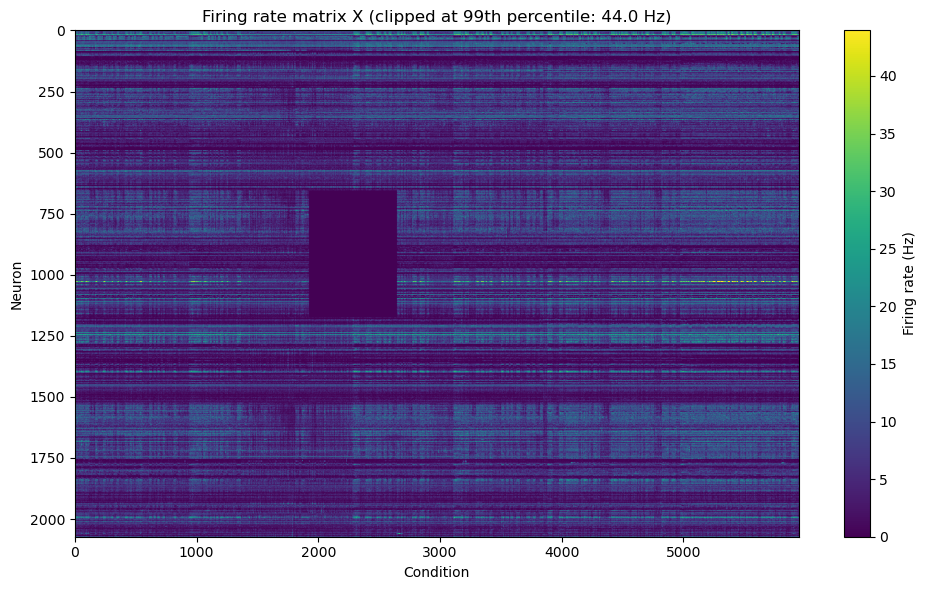

In [7]:
vmax = np.percentile(X, 99)  # upper limit for colormap scaling

plt.figure(figsize=(10, 6))
plt.imshow(X, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(label='Firing rate (Hz)')
plt.xlabel('Condition')
plt.ylabel('Neuron')
plt.title(f'Firing rate matrix X (clipped at 99th percentile: {vmax:.1f} Hz)')
plt.tight_layout()
plt.show()


Step 3: PCA on X

In [8]:
# --- Transpose so: conditions = rows, neurons = columns ---
X_pca_input = X.T  # shape: (nConds, nNeurons)

# --- Z-score each neuron (i.e. each column) ---
scaler = StandardScaler()
X_zscored = scaler.fit_transform(X_pca_input)

# --- PCA ---
pca = PCA()
score = pca.fit_transform(X_zscored)
explained = pca.explained_variance_ratio_ * 100
components = pca.components_

# --- Report explained variance ---
print(f'PCA: First 100 PCs explain {np.sum(explained[:100]):.1f}% of the variance')


PCA: First 100 PCs explain 31.8% of the variance


Step 4: Visualize PCA Loadings Across Neurons

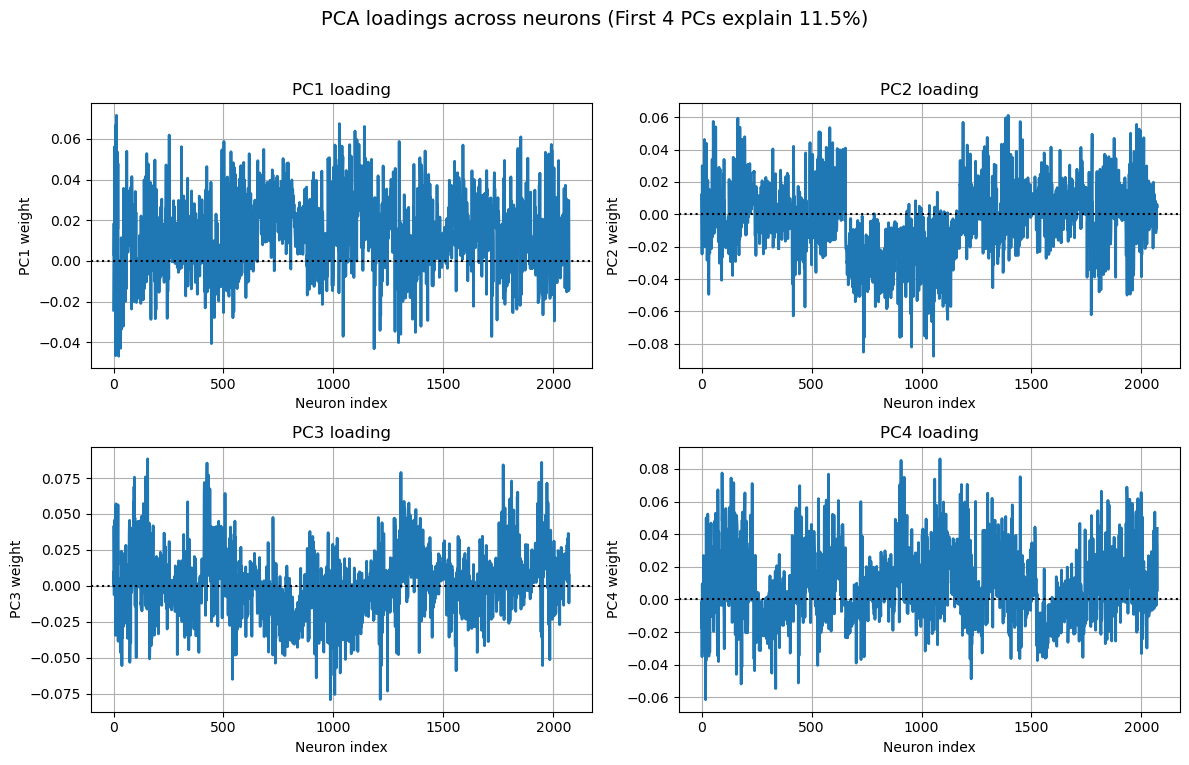

In [9]:
n_show = 4  # number of PCs to show
plt.figure(figsize=(12, 8))
for k in range(n_show):
    plt.subplot(2, 2, k + 1)
    plt.plot(components[k], linewidth=2)
    plt.axhline(0, color='k', linestyle=':')
    plt.title(f'PC{k+1} loading')
    plt.xlabel('Neuron index')
    plt.ylabel(f'PC{k+1} weight')
    plt.grid(True)

plt.suptitle(f'PCA loadings across neurons (First {n_show} PCs explain {np.sum(explained[:n_show]):.1f}%)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Step 5: NMF on X

In [10]:
K = 4  # number of latent ensembles/components

# Run NMF
nmf = NMF(n_components=K, init='nndsvda', max_iter=1000, random_state=0)
W_nmf = nmf.fit_transform(X)       # shape: (nNeurons, K)
H_nmf = nmf.components_            # shape: (K, nConds)

# Reconstruct and compute Frobenius error
X_hat = np.dot(W_nmf, H_nmf)
recon_error = np.linalg.norm(X - X_hat, 'fro') ** 2

print(f'NMF reconstruction error (Frobenius²): {recon_error:.3f}')


NMF reconstruction error (Frobenius²): 523137130.992


Step 6: Visualize NMF Ensembles (Columns of W_nmf)

/var/folders/vg/zn214j451l16lbthr9mtqw8m0000gr/T/ipykernel_65854/2153726748.py:4: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(W_nmf[:, k], use_line_collection=True)


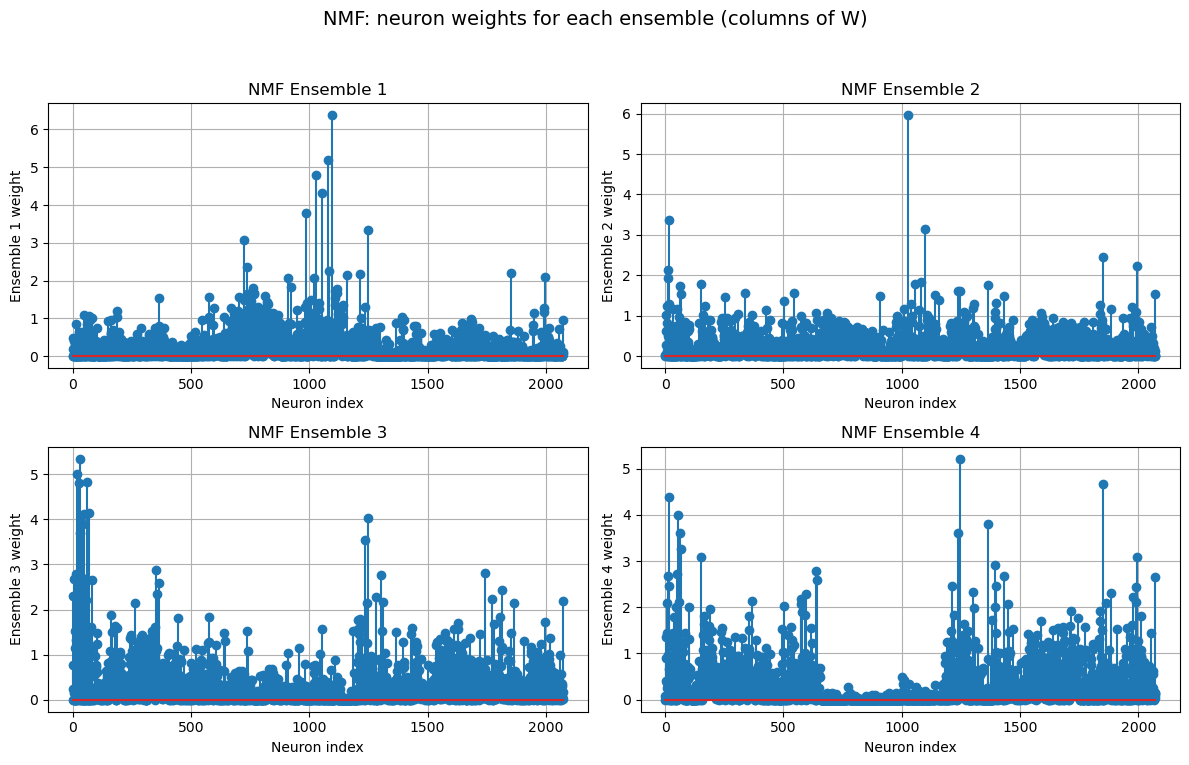

In [11]:
plt.figure(figsize=(12, 8))
for k in range(K):
    plt.subplot(2, 2, k + 1)
    plt.stem(W_nmf[:, k], use_line_collection=True)
    plt.xlabel('Neuron index')
    plt.ylabel(f'Ensemble {k+1} weight')
    plt.title(f'NMF Ensemble {k+1}')
    plt.grid(True)

plt.suptitle('NMF: neuron weights for each ensemble (columns of W)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Step 7: Visualize Ensemble Activations Across Conditions (H_nmf)

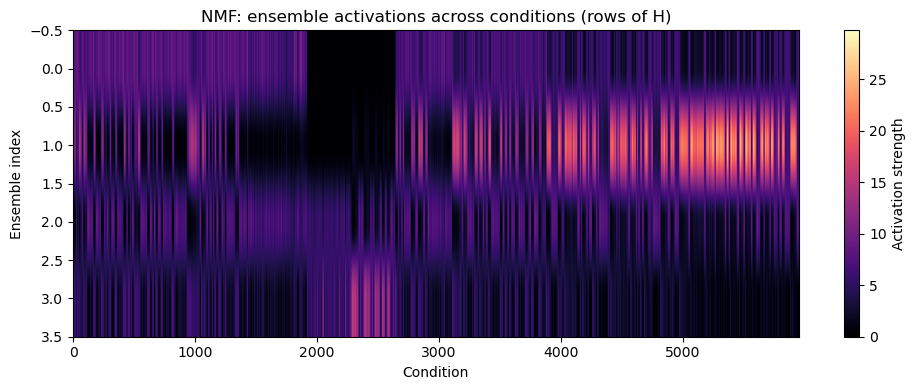

In [12]:
plt.figure(figsize=(10, 4))
plt.imshow(H_nmf, aspect='auto', cmap='magma')
plt.colorbar(label='Activation strength')
plt.xlabel('Condition')
plt.ylabel('Ensemble index')
plt.title('NMF: ensemble activations across conditions (rows of H)')
plt.tight_layout()
plt.show()


Step 8 (Rescaled): Reorder Neurons by Dominant Ensemble

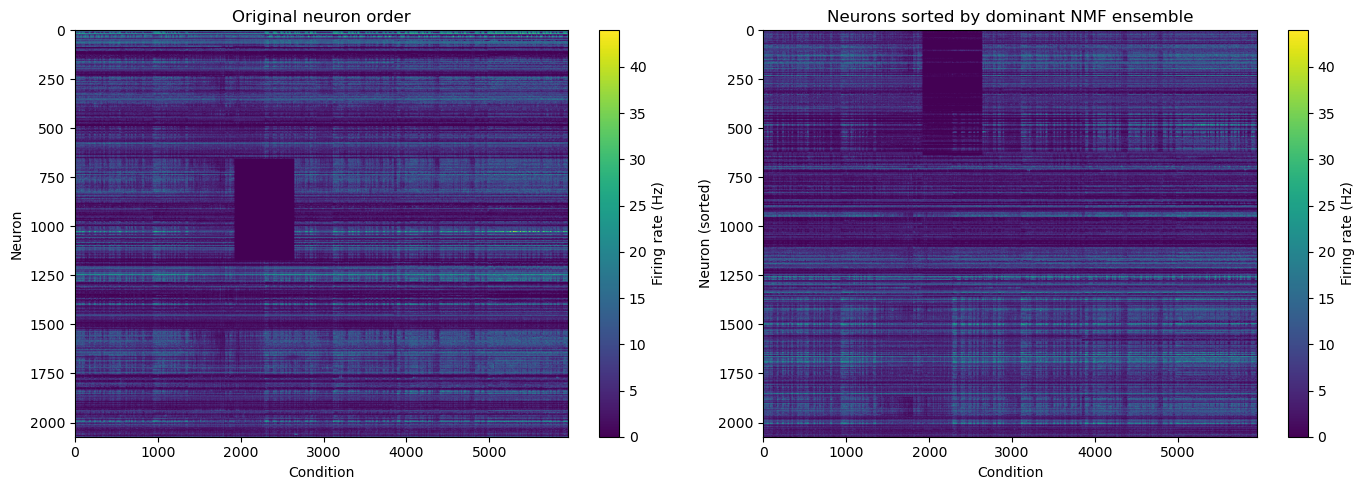

In [13]:
# --- Find dominant ensemble for each neuron ---
dominant_ensemble = np.argmax(W_nmf, axis=1)
sort_idx = np.argsort(dominant_ensemble)

# --- Rescale upper limit for better contrast ---
vmax = np.percentile(X, 99)

# --- Plot original vs sorted ---
plt.figure(figsize=(14, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(X, aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(label='Firing rate (Hz)')
plt.title('Original neuron order')
plt.xlabel('Condition')
plt.ylabel('Neuron')

# Sorted
plt.subplot(1, 2, 2)
plt.imshow(X[sort_idx, :], aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
plt.colorbar(label='Firing rate (Hz)')
plt.title('Neurons sorted by dominant NMF ensemble')
plt.xlabel('Condition')
plt.ylabel('Neuron (sorted)')

plt.tight_layout()
plt.show()
